In [ ]:
!nvidia-smi

Mon Sep  7 18:08:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%bash
set -e
pip install -q "numpy<2"
pip install -q pycolmap trimesh pymeshlab opencv-python plotly ultralytics av
apt-get -qq update
apt-get -qq install -y colmap
git clone --recursive https://github.com/cvg/Hierarchical-Localization.git
cd Hierarchical-Localization && pip install -q -e . && cd ..
git clone https://github.com/nerfstudio-project/nerfstudio.git
cd nerfstudio
sed -i '/open3d/d' pyproject.toml
grep -rl "^import open3d" . 2>/dev/null | xargs -r sed -i 's/^import open3d/# import open3d/'
grep -rl "^from open3d" . 2>/dev/null | xargs -r sed -i 's/^from open3d/# from open3d/'
pip install -q -e . && cd ..
pip install -q gsplat
echo "PHASE 2 INSTALL COMPLETE"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 104.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.4/106.4 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 6.8 MB/s eta 0:00:00
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.8.23 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.1 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.11.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.11.1 requires numpy>=2.0, bu

In [ ]:
import os
os._exit(0)

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/aeromesh_checkpoints"
os.makedirs(DRIVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
import numpy as np, cv2, ultralytics, pycolmap, nerfstudio, hloc
print("numpy:", np.__version__, "| cv2:", cv2.__version__, "| ultralytics:", ultralytics.__version__)
print("pycolmap OK | nerfstudio OK | hloc OK")

import re
from pathlib import Path
target_file = Path("/content/nerfstudio/nerfstudio/data/dataparsers/nerfstudio_dataparser.py")
content = target_file.read_text()
new_method = '''    def _load_3D_points(self, ply_file_path: Path, transform_matrix: torch.Tensor, scale_factor: float):
        xyzs, rgbs = [], []
        with open(ply_file_path, "r") as f:
            assert f.readline().strip() == "ply"
            num_vertices = 0
            while True:
                line = f.readline()
                if line.startswith("element vertex"):
                    num_vertices = int(line.split()[-1])
                if line.strip() == "end_header":
                    break
            for _ in range(num_vertices):
                parts = f.readline().split()
                xyzs.append((float(parts[0]), float(parts[1]), float(parts[2])))
                rgbs.append((int(parts[3]), int(parts[4]), int(parts[5])))
        if len(xyzs) == 0:
            return None
        points3D = torch.from_numpy(np.array(xyzs, dtype=np.float32))
        points3D = (torch.cat((points3D, torch.ones_like(points3D[..., :1])), -1) @ transform_matrix.T)
        points3D *= scale_factor
        points3D_rgb = torch.from_numpy(np.array(rgbs, dtype=np.uint8))
        return {"points3D_xyz": points3D, "points3D_rgb": points3D_rgb}

'''
pattern = re.compile(r"    def _load_3D_points\(self, ply_file_path.*?\n(?=    def |\Z)", re.DOTALL)
assert len(pattern.findall(content)) == 1
target_file.write_text(pattern.sub(new_method, content))
print("Open3D patch applied")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
numpy: 1.26.4 | cv2: 4.11.0 | ultralytics: 8.4.143
pycolmap OK | nerfstudio OK | hloc OK
Open3D patch applied


In [ ]:
import glob, cv2

candidates = glob.glob("/content/new_test*")
assert len(candidates) >= 1, "No file starting with 'new_test' found — check the upload"
VIDEO_PATH = candidates[0]

cap = cv2.VideoCapture(VIDEO_PATH)
source_fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration_sec = frame_count / source_fps
cap.release()

TARGET_FRAME_COUNT = 185
target_fps = TARGET_FRAME_COUNT / duration_sec
print(f"Using: {VIDEO_PATH}")
print(f"Source fps: {source_fps:.2f} | duration: {duration_sec:.1f}s | target sampling fps: {target_fps:.2f}")

Using: /content/new_test.mp4
Source fps: 30.00 | duration: 37.3s | target sampling fps: 4.96


In [ ]:
from pathlib import Path
from ultralytics import YOLO

OUTPUT_DIR = Path("/content/frames")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MASK_CLASSES = {0, 2, 3, 5, 7, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23}
model = YOLO("yolov8n-seg.pt")

def extract(max_frames=None):
    cap = cv2.VideoCapture(VIDEO_PATH)
    frame_interval = max(1, round(source_fps / target_fps))
    frame_idx = saved_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if frame_idx % frame_interval == 0:
            results = model(frame, verbose=False)[0]
            if results.masks is not None:
                for cls_id, mask in zip(results.boxes.cls.tolist(), results.masks.data):
                    if int(cls_id) in MASK_CLASSES:
                        m = cv2.resize(mask.cpu().numpy(), (frame.shape[1], frame.shape[0]))
                        frame[m > 0.5] = 0
            cv2.imwrite(str(OUTPUT_DIR / f"frame_{saved_idx:05d}.jpg"), frame)
            saved_idx += 1
            if max_frames and saved_idx >= max_frames: break
        frame_idx += 1
    cap.release()
    return saved_idx

n = extract(max_frames=15)
print(f"Test batch: saved {n} frames")

Test batch: saved 15 frames


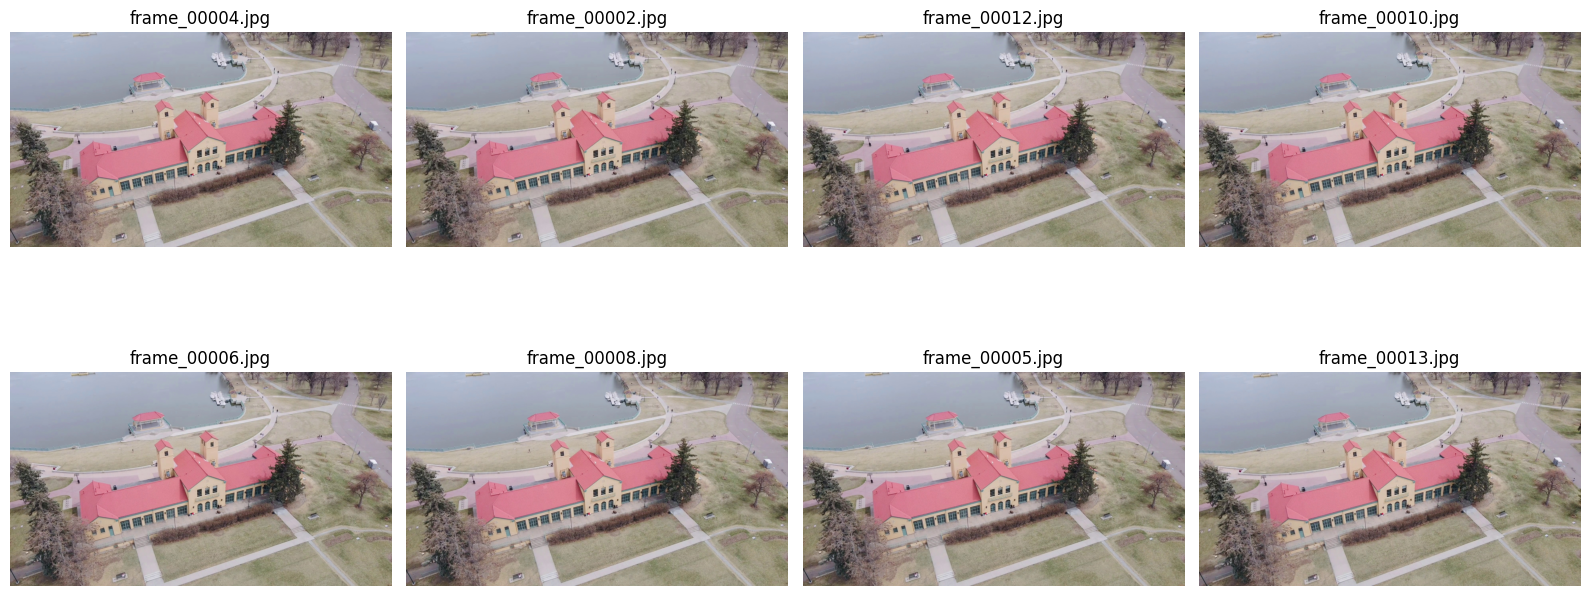

In [ ]:
import matplotlib.pyplot as plt, random
sample = random.sample(sorted(OUTPUT_DIR.glob("*.jpg")), min(8, n))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, fp in zip(axes.flat, sample):
    ax.imshow(cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB))
    ax.set_title(fp.name); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
import shutil
shutil.rmtree(OUTPUT_DIR, ignore_errors=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
n = extract(max_frames=None)
print(f"Saved {n} frames")
shutil.copytree(OUTPUT_DIR, f"{DRIVE_DIR}/new_test_frames", dirs_exist_ok=True)
print("Backed up to Drive")

Saved 187 frames
Backed up to Drive


In [ ]:
from hloc import extract_features, match_features, reconstruction, pairs_from_exhaustive

IMAGES_DIR = OUTPUT_DIR
OUTPUTS_DIR = Path("/content/outputs/sfm")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
SFM_PAIRS = OUTPUTS_DIR / "pairs-exhaustive.txt"
SFM_DIR = OUTPUTS_DIR / "0"

feature_conf = extract_features.confs["aliked-n16"]
matcher_conf = match_features.confs["aliked+lightglue"]
image_list = [p.name for p in sorted(IMAGES_DIR.glob("*.jpg"))]

pairs_from_exhaustive.main(SFM_PAIRS, image_list=image_list)
feature_path = extract_features.main(feature_conf, IMAGES_DIR, OUTPUTS_DIR)
match_path = match_features.main(matcher_conf, SFM_PAIRS, feature_conf["output"], OUTPUTS_DIR)
model_ = reconstruction.main(SFM_DIR, IMAGES_DIR, SFM_PAIRS, feature_path, match_path)
print(f"Registered: {model_.num_reg_images()} / {len(image_list)}")

shutil.copytree(OUTPUTS_DIR, f"{DRIVE_DIR}/new_test_sfm", dirs_exist_ok=True)
print("Backed up to Drive")

[2026/09/07 18:21:02 hloc INFO] Found 17391 pairs.
[2026/09/07 18:21:02 hloc INFO] Extracting local features with configuration:
{'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
 'output': 'feats-aliked-n16',
 'preprocessing': {'grayscale': False, 'resize_max': 1024}}
[2026/09/07 18:21:02 hloc INFO] Found 187 images in root /content/frames.


Downloading: "https://github.com/Shiaoming/ALIKED/raw/main/models/aliked-n16.pth" to /root/.cache/torch/hub/checkpoints/aliked-n16.pth


100%|██████████| 2.61M/2.61M [00:00<00:00, 212MB/s]
100%|██████████| 187/187 [00:17<00:00, 10.76it/s]
[2026/09/07 18:21:21 hloc INFO] Finished exporting features.
[2026/09/07 18:21:21 hloc INFO] Matching local features with configuration:
{'model': {'features': 'aliked', 'name': 'lightglue'},
 'output': 'matches-aliked-lightglue'}


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth" to /root/.cache/torch/hub/checkpoints/aliked_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:01<00:00, 47.6MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/17391 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if 

Registered: 187 / 187
Backed up to Drive


In [ ]:
import struct, json

DATA_DIR = Path("/content/nerfstudio_data")
COLMAP_SPARSE_DIR = Path("/content/outputs/colmap/sparse/0")
COLMAP_SPARSE_DIR.mkdir(parents=True, exist_ok=True)
source_dir = next((d for d in [SFM_DIR, SFM_DIR / "models" / "0"] if (d / "cameras.bin").exists()))
for fname in ["cameras.bin", "images.bin", "points3D.bin"]:
    shutil.copy(source_dir / fname, COLMAP_SPARSE_DIR / fname)

!ns-process-data images --data /content/frames --output-dir {DATA_DIR} --skip-colmap --colmap-model-path {COLMAP_SPARSE_DIR}

def read_points3D_binary(path):
    xyzs, rgbs = [], []
    with open(path, "rb") as fid:
        n_pts = struct.unpack("<Q", fid.read(8))[0]
        for _ in range(n_pts):
            data = struct.unpack("<QdddBBBd", fid.read(43))
            xyzs.append(data[1:4]); rgbs.append(data[4:7])
            tl = struct.unpack("<Q", fid.read(8))[0]
            fid.read(8 * tl)
    return np.array(xyzs), np.array(rgbs, dtype=np.uint8)

xyzs, rgbs = read_points3D_binary(COLMAP_SPARSE_DIR / "points3D.bin")
ply_path = DATA_DIR / "sparse_pc.ply"
with open(ply_path, "w") as f:
    f.write(f"ply\nformat ascii 1.0\nelement vertex {len(xyzs)}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write("property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n")
    for (x,y,z),(r,g,b) in zip(xyzs, rgbs):
        f.write(f"{x} {y} {z} {int(r)} {int(g)} {int(b)}\n")
print(f"Parsed {len(xyzs)} points -> {ply_path}")

# Nerfstudio reads ply_file_path FROM transforms.json — writing the file isn't enough on its own
with open(DATA_DIR / "transforms.json") as f:
    transforms = json.load(f)
transforms["ply_file_path"] = "sparse_pc.ply"
with open(DATA_DIR / "transforms.json", "w") as f:
    json.dump(transforms, f, indent=4)
print("transforms.json ply_file_path -> sparse_pc.ply")

shutil.copytree(DATA_DIR, f"{DRIVE_DIR}/new_test_nerfstudio_data", dirs_exist_ok=True)
print("Backed up to Drive")

/content/nerfstudio/nerfstudio/process_data/process_data_utils.py:205: SyntaxWarning: invalid escape sequence '\,'
  select_cmd = "select='" + "+".join([f"eq(n\,{idx})" for idx in frame_indices]) + "',setpts=N/TB,"
[19:03:16] 🎉 Done copying images with prefix 'frame_'.                                        ]8;id=358506;file:///content/nerfstudio/nerfstudio/process_data/process_data_utils.py\process_data_utils.py]8;;\:]8;id=695440;file:///content/nerfstudio/nerfstudio/process_data/process_data_utils.py#348\348]8;;\
(  ●   ) Copying images...
{1: Camera(id=1, model='SIMPLE_RADIAL', width=1920, height=1080, params=array([1.44348441e+03, 9.60000000e+02, 
5.40000000e+02, 2.26202645e-02])), 2: Camera(id=2, model='SIMPLE_RADIAL', width=1920, height=1080, 
params=array([1.44294162e+03, 9.60000000e+02, 5.40000000e+02, 2.28301105e-02])), 3: Camera(id=3, model='SIMPLE_RADIAL', 
width=1920, height=1080, params=array([1.44312633e+03, 9.60000000e+02, 5.40000000e+02, 2.26803101e-02])), 4: 
C

In [ ]:
import json
from pathlib import Path

DATA_DIR = Path("/content/nerfstudio_data")

with open(DATA_DIR / "transforms.json") as f:
    transforms = json.load(f)

ply_ref = transforms.get("ply_file_path")
print("transforms.json ply_file_path:", ply_ref)

if ply_ref is None:
    print("MISSING — re-run Cell 11")
else:
    resolved = DATA_DIR / ply_ref
    exists = resolved.exists()
    print("Resolves to:", resolved, "| exists:", exists)
    if exists:
        with open(resolved) as f:
            first_line = f.readline().strip()
        valid = first_line == "ply"
        print("First line:", repr(first_line), "| valid:", valid)
        print("SAFE TO LAUNCH TRAINING" if valid else "NOT SAFE — investigate before Cell 13")
    else:
        print("File missing at resolved path — re-run Cell 11")

transforms.json ply_file_path: sparse_pc.ply
Resolves to: /content/nerfstudio_data/sparse_pc.ply | exists: True
First line: 'ply' | valid: True
SAFE TO LAUNCH TRAINING


In [ ]:
os.environ["MAX_JOBS"] = "1"
import subprocess

log_file = open("/content/train_log.txt", "w")
process = subprocess.Popen(
    ["ns-train", "splatfacto", "--data", str(DATA_DIR),
     "--max-num-iterations", "7000", "--viewer.quit-on-train-completion", "True", "--vis", "tensorboard"],
    stdout=log_file, stderr=subprocess.STDOUT, env=os.environ,
)
print(f"Launched, PID: {process.pid}")

Launched, PID: 24499


In [ ]:
!tail -n 20 /content/train_log.txt

6940 (99.14%)       44.212 ms            2 s, 652.742 ms      11.70 M               
6950 (99.29%)       43.536 ms            2 s, 176.797 ms      11.88 M               
6960 (99.43%)       43.007 ms            1 s, 720.262 ms      12.03 M               
6970 (99.57%)       42.813 ms            1 s, 284.379 ms      12.08 M               
6980 (99.71%)       43.389 ms            867.774 ms           11.93 M               
6990 (99.86%)       44.566 ms            445.657 ms           11.61 M               
6999 (99.99%)                                                                       
╭───────────────────────────────────── 🎉 Training Finished 🎉 ─────────────────────────────────────╮
│                        ╷                                                                          │
│   Config File          │ outputs/nerfstudio_data/splatfacto/2026-09-07_190358/config.yml          │
│   Checkpoint Directory │ outputs/nerfstudio_data/splatfacto/2026-09-07_190358/nerfstudio_models   │

In [ ]:
runs = sorted(Path("outputs/nerfstudio_data/splatfacto").glob("*"))
if runs:
    latest_run = runs[-1]
    shutil.copytree(latest_run, f"{DRIVE_DIR}/{latest_run.name}", dirs_exist_ok=True)
    print(f"Backed up {latest_run}")

Backed up outputs/nerfstudio_data/splatfacto/2026-09-07_190358


In [ ]:
Path("/content/outputs/renders").mkdir(parents=True, exist_ok=True)
Path("/content/outputs/export").mkdir(parents=True, exist_ok=True)
config_path = latest_run / "config.yml"
!ns-render interpolate --load-config {config_path} --output-path /content/outputs/renders/interpolate.mp4
!ns-render spiral --load-config {config_path} --output-path /content/outputs/renders/spiral.mp4
!ns-export gaussian-splat --load-config {config_path} --output-dir /content/outputs/export

/content/nerfstudio/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/content/nerfstudio/nerfstudio/field_components/activations.py:38: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
[19:50:27] Auto image downscale factor of 2                                                 ]8;id=933581;file:///content/nerfstudio/nerfstudio/data/dataparsers/nerfstudio_dataparser.py\nerfstudio_dataparser.py]8;;\:]8;id=160962;file:///content/nerfstudio/nerfstudio/data/dataparsers/nerfstudio_dataparser.py#468\468]8;;\
Loading latest checkpoint from load_dir
Traceback (most recent call last):
  File "/usr/local/bin/ns-render", line 8, in <module>
    sys.exit(entrypoint())
             ~~~~~~~~~~^^
  File "/content/nerf

In [ ]:
import os
for d in ["/content/outputs/renders", "/content/outputs/export"]:
    print(f"--- {d} ---")
    if Path(d).exists():
        for f in os.listdir(d):
            print(" ", f)
    else:
        print("  (does not exist)")

--- /content/outputs/renders ---
--- /content/outputs/export ---


In [ ]:
from pathlib import Path

eval_utils_path = Path("/content/nerfstudio/nerfstudio/utils/eval_utils.py")
content = eval_utils_path.read_text()

old = 'loaded_state = torch.load(load_path, map_location="cpu")'
new = 'loaded_state = torch.load(load_path, map_location="cpu", weights_only=False)'

assert content.count(old) == 1, f"Expected exactly 1 occurrence, found {content.count(old)}"
eval_utils_path.write_text(content.replace(old, new))
print("Patched eval_utils.py — weights_only=False")

Patched eval_utils.py — weights_only=False


In [ ]:
import subprocess

print("config_path:", config_path, "| exists:", config_path.exists())

commands = [
    ["ns-render", "interpolate", "--load-config", str(config_path), "--output-path", "/content/outputs/renders/interpolate.mp4"],
    ["ns-render", "spiral", "--load-config", str(config_path), "--output-path", "/content/outputs/renders/spiral.mp4"],
    ["ns-export", "gaussian-splat", "--load-config", str(config_path), "--output-dir", "/content/outputs/export"],
]

for cmd in commands:
    print("="*25, " ".join(cmd), "="*25)
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("RETURN CODE:", result.returncode)
    print(result.stdout[-2000:])
    print(result.stderr[-2000:])

config_path: outputs/nerfstudio_data/splatfacto/2026-09-07_190358/config.yml | exists: True
========================= ns-render interpolate --load-config outputs/nerfstudio_data/splatfacto/2026-09-07_190358/config.yml --output-path /content/outputs/renders/interpolate.mp4 =========================
RETURN CODE: 0
[20:03:48] Auto image downscale factor of 2                                                 nerfstudio_dataparser.py:468
Loading latest checkpoint from load_dir
✅ Done loading checkpoint from 
outputs/nerfstudio_data/splatfacto/2026-09-07_190358/nerfstudio_models/step-000006999.ckpt
Creating trajectory video
🎥 Rendering 🎥 ━━━━━━━━━━━━━━━━━━━━━━ 170/170(100.0%) 16.72 fps 0:00:00 0:00:14
╭─────────────── 🎉 Render Complete 🎉 ────────────────╮
│         ╷                                            │
│   Video │ /content/outputs/renders/interpolate.mp4   │
│         ╵                                            │
╰──────────────────────────────────────────────────────╯

/content/nerf

In [ ]:
for cmd in commands:
    print("="*25, " ".join(cmd), "="*25)
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("RETURN CODE:", result.returncode)
    print(result.stdout[-2000:])
    print(result.stderr[-2000:])

========================= ns-render interpolate --load-config outputs/nerfstudio_data/splatfacto/2026-09-07_190358/config.yml --output-path /content/outputs/renders/interpolate.mp4 =========================
RETURN CODE: 0
[20:05:27] Auto image downscale factor of 2                                                 nerfstudio_dataparser.py:468
Loading latest checkpoint from load_dir
✅ Done loading checkpoint from 
outputs/nerfstudio_data/splatfacto/2026-09-07_190358/nerfstudio_models/step-000006999.ckpt
Creating trajectory video
🎥 Rendering 🎥 ━━━━━━━━━━━━━━━━━━━━━━ 170/170(100.0%) 20.18 fps 0:00:00 0:00:12
╭─────────────── 🎉 Render Complete 🎉 ────────────────╮
│         ╷                                            │
│   Video │ /content/outputs/renders/interpolate.mp4   │
│         ╵                                            │
╰──────────────────────────────────────────────────────╯

/content/nerfstudio/nerfstudio/field_components/activations.py:32: FutureWarning: `torch.cuda.amp.custom_

In [ ]:
for f in ["/content/outputs/renders/interpolate.mp4",
          "/content/outputs/renders/spiral.mp4",
          "/content/outputs/export/point_cloud.ply"]:
    print(f"{'✅' if Path(f).exists() else '❌ MISSING'}  {f}")

✅  /content/outputs/renders/interpolate.mp4
❌ MISSING  /content/outputs/renders/spiral.mp4
❌ MISSING  /content/outputs/export/point_cloud.ply


In [ ]:
import os
print(os.listdir("/content/outputs/export"))
print(os.listdir("/content/outputs/renders"))

['splat.ply']
['interpolate.mp4']


In [ ]:
backup_targets = {
    "frames": "/content/frames",
    "sfm_output": "/content/outputs/sfm",
    "nerfstudio_data": "/content/nerfstudio_data",
    "trained_model": str(latest_run) if 'latest_run' in dir() else None,
    "renders": "/content/outputs/renders",
    "export": "/content/outputs/export",
}
for label, src in backup_targets.items():
    if src and Path(src).exists():
        shutil.copytree(src, f"{DRIVE_DIR}/new_test_{label}", dirs_exist_ok=True)
        print(f"✅ {label}")
    else:
        print(f"❌ {label} not found")

✅ frames
✅ sfm_output
✅ nerfstudio_data
✅ trained_model
✅ renders
✅ export


In [ ]:
!apt-get -qq install -y exiftool
!exiftool /content/new_test* 2>/dev/null | grep -i -E "gps|latitude|longitude"

Selecting previously unselected package libarchive-zip-perl.
(Reading database ... 123923 files and directories currently installed.)
Preparing to unpack .../libarchive-zip-perl_1.68-1_all.deb ...
Unpacking libarchive-zip-perl (1.68-1) ...
Selecting previously unselected package libimage-exiftool-perl.
Preparing to unpack .../libimage-exiftool-perl_12.40+dfsg-1_all.deb ...
Unpacking libimage-exiftool-perl (12.40+dfsg-1) ...
Selecting previously unselected package libmime-charset-perl.
Preparing to unpack .../libmime-charset-perl_1.012.2-1_all.deb ...
Unpacking libmime-charset-perl (1.012.2-1) ...
Selecting previously unselected package libsombok3:amd64.
Preparing to unpack .../libsombok3_2.4.0-2_amd64.deb ...
Unpacking libsombok3:amd64 (2.4.0-2) ...
Selecting previously unselected package libunicode-linebreak-perl.
Preparing to unpack .../libunicode-linebreak-perl_0.0.20190101-1build3_amd64.deb ...
Unpacking libunicode-linebreak-perl (0.0.20190101-1build3) ...
Setting up libsombok3:amd

In [ ]:
import plotly.graph_objects as go

xyzs, rgbs = read_points3D_binary(COLMAP_SPARSE_DIR / "points3D.bin")

fig = go.Figure(data=[go.Scatter3d(
    x=xyzs[:,0], y=xyzs[:,1], z=xyzs[:,2],
    mode='markers',
    marker=dict(size=1.5, color=rgbs/255.0),
)])
fig.update_layout(width=900, height=700, scene=dict(aspectmode='data'))
fig.show()

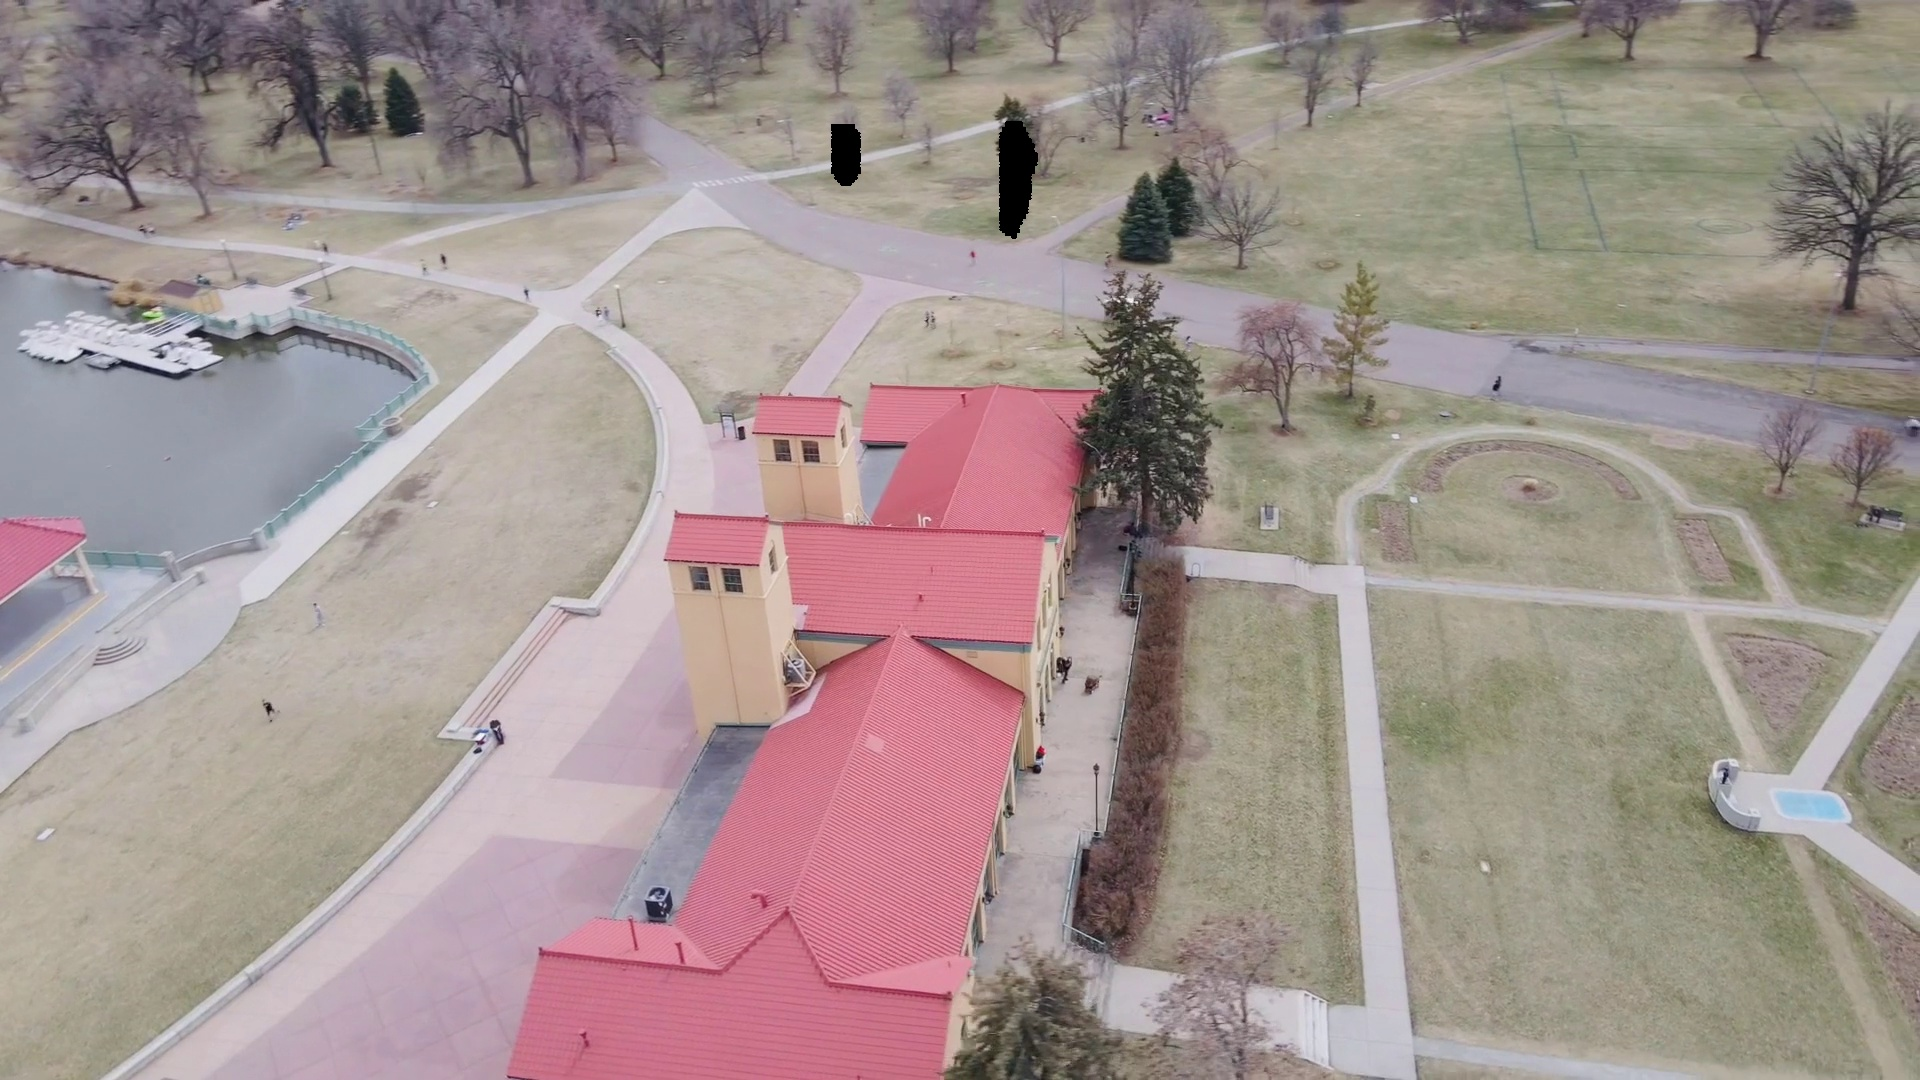

In [ ]:
from IPython.display import Image, display
import os

frame_files = sorted(os.listdir(OUTPUT_DIR))
mid_frame = OUTPUT_DIR / frame_files[len(frame_files)//2]
display(Image(filename=str(mid_frame)))

In [ ]:
from IPython.display import Video
Video("/content/outputs/renders/interpolate.mp4", embed=True, width=800)

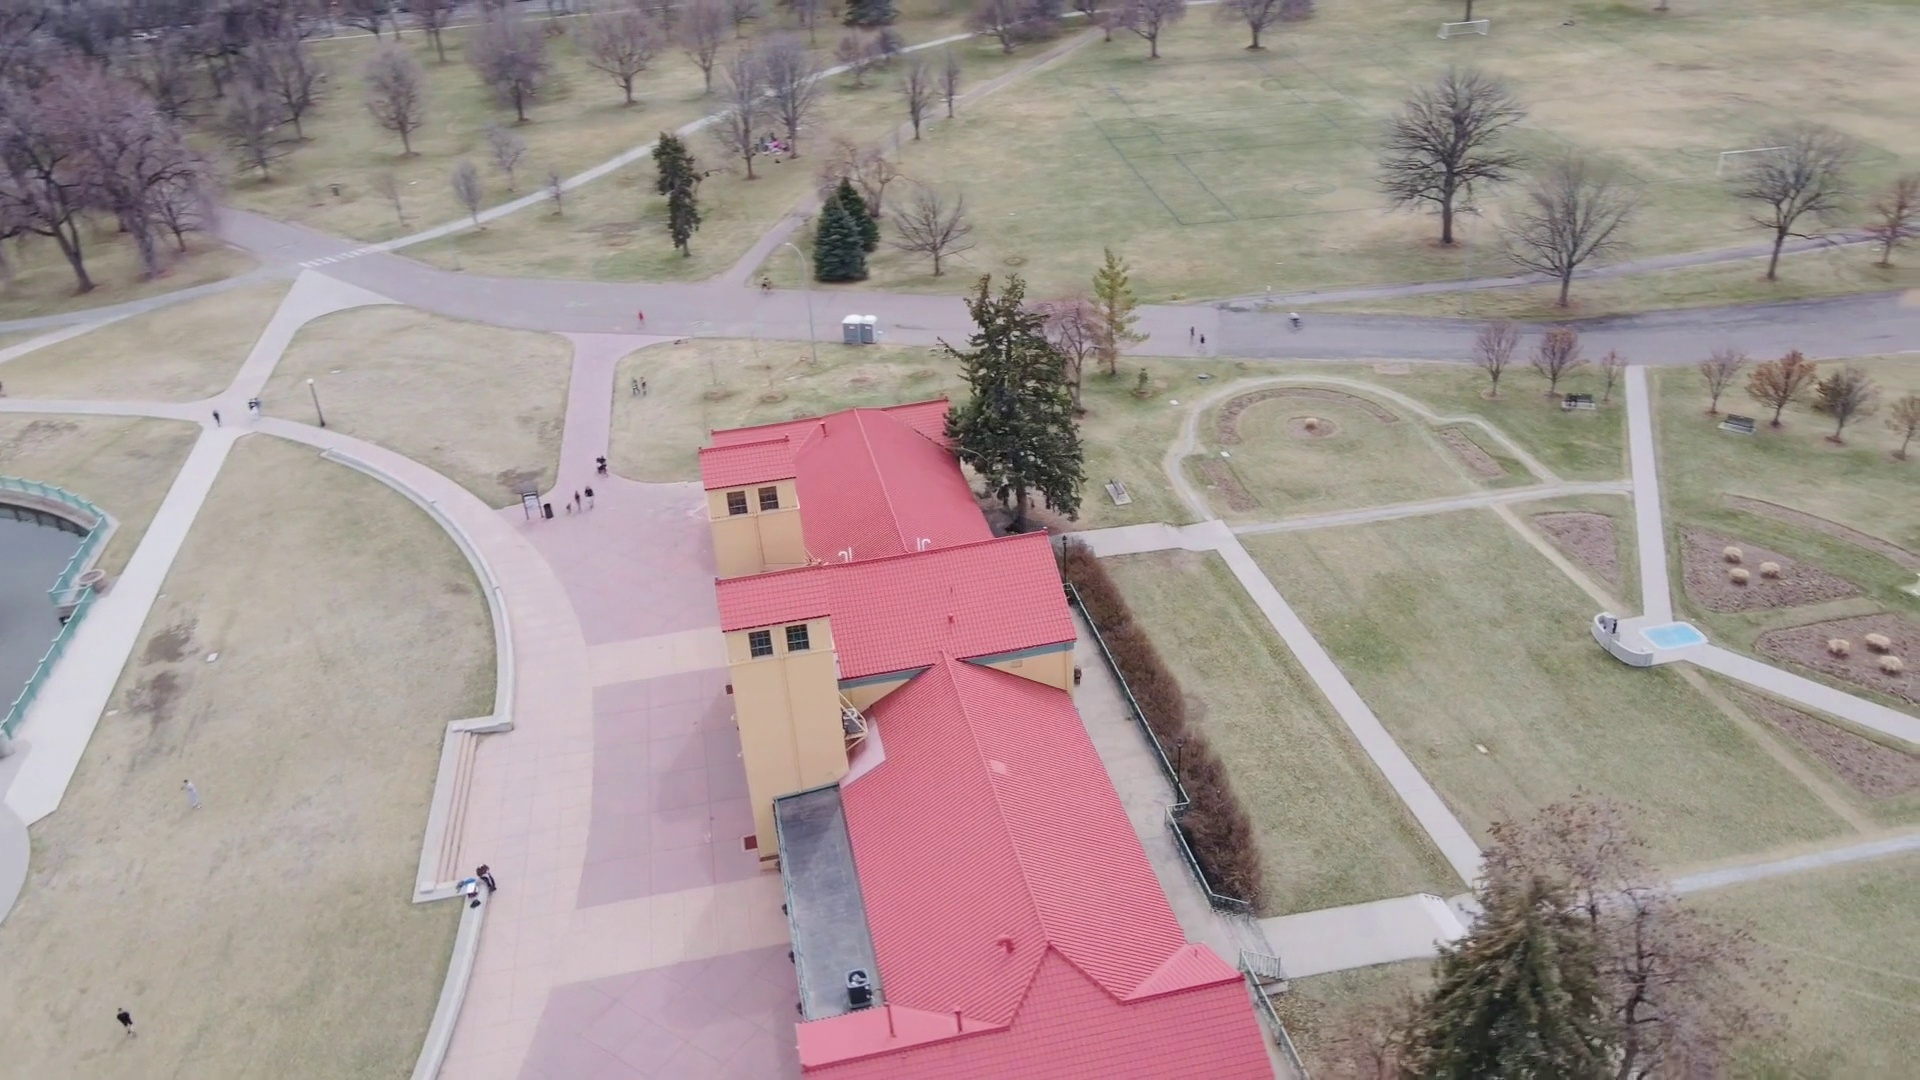

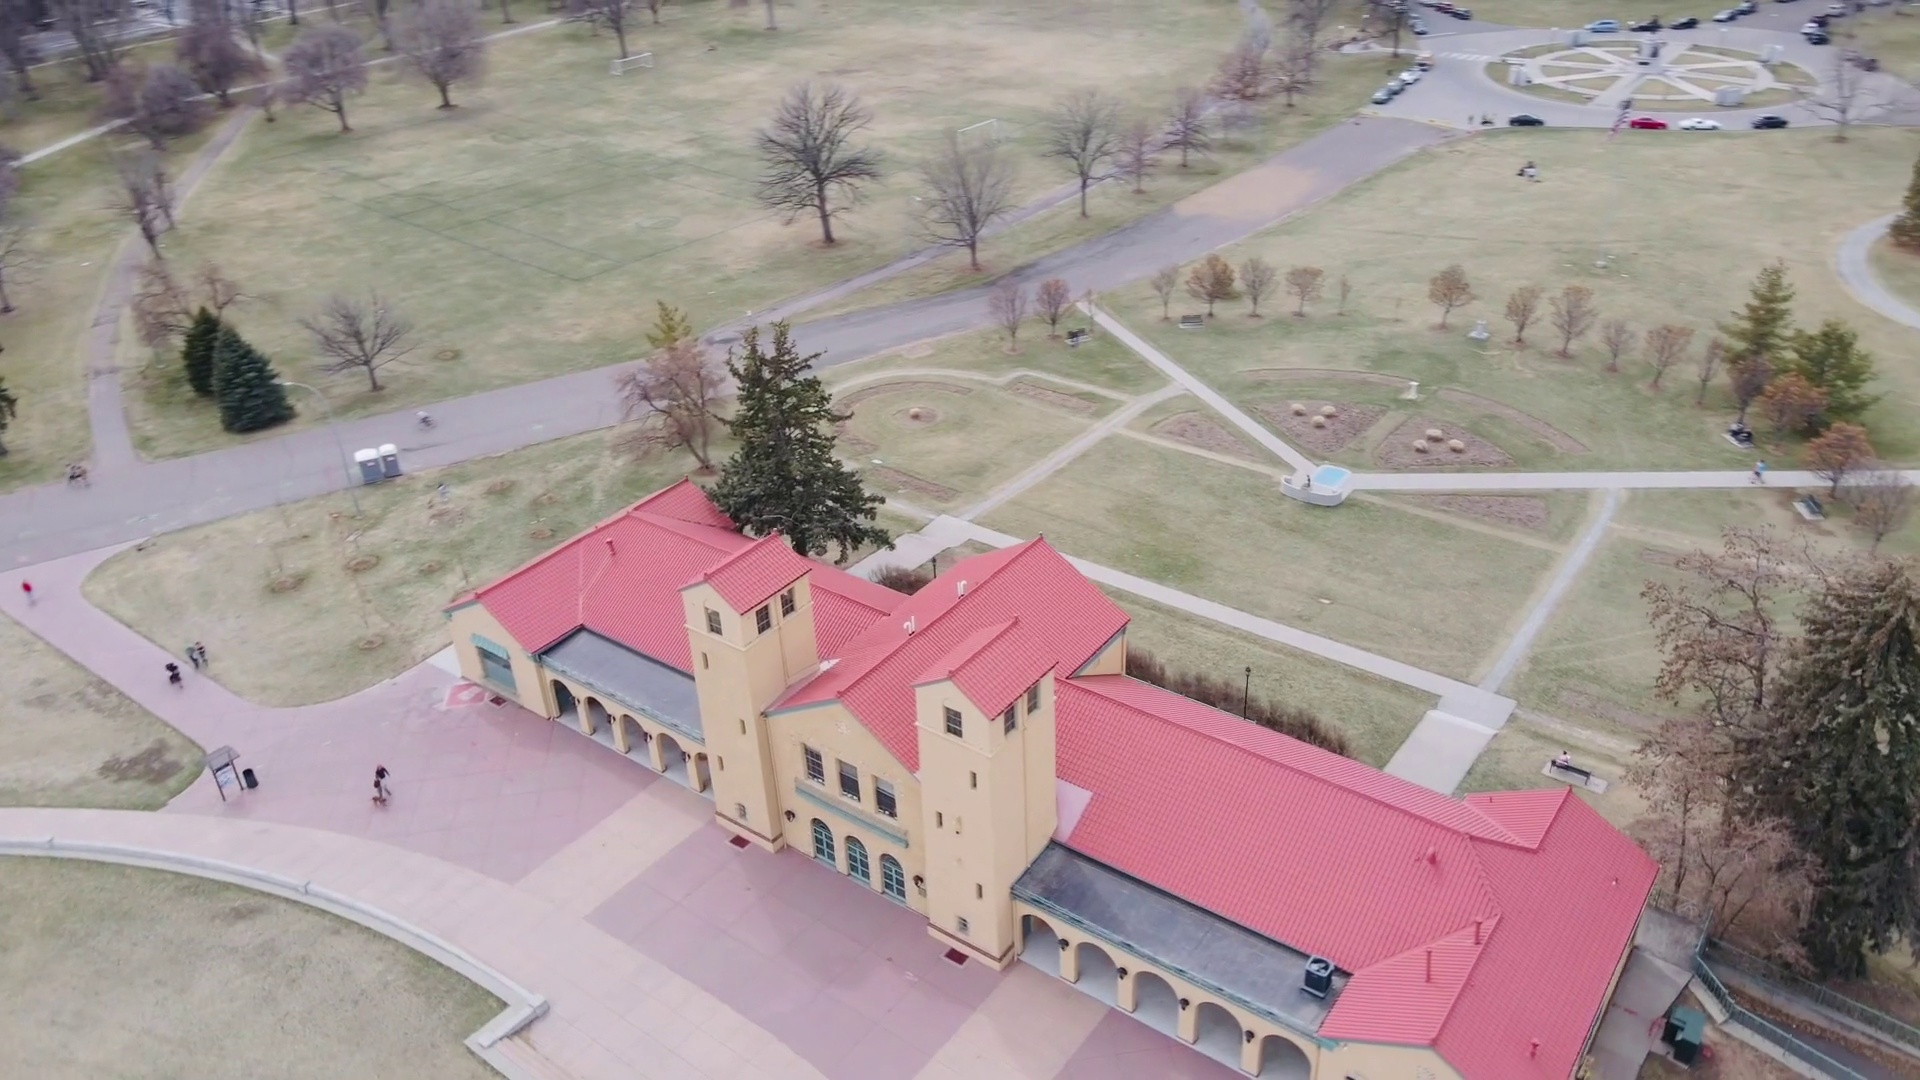

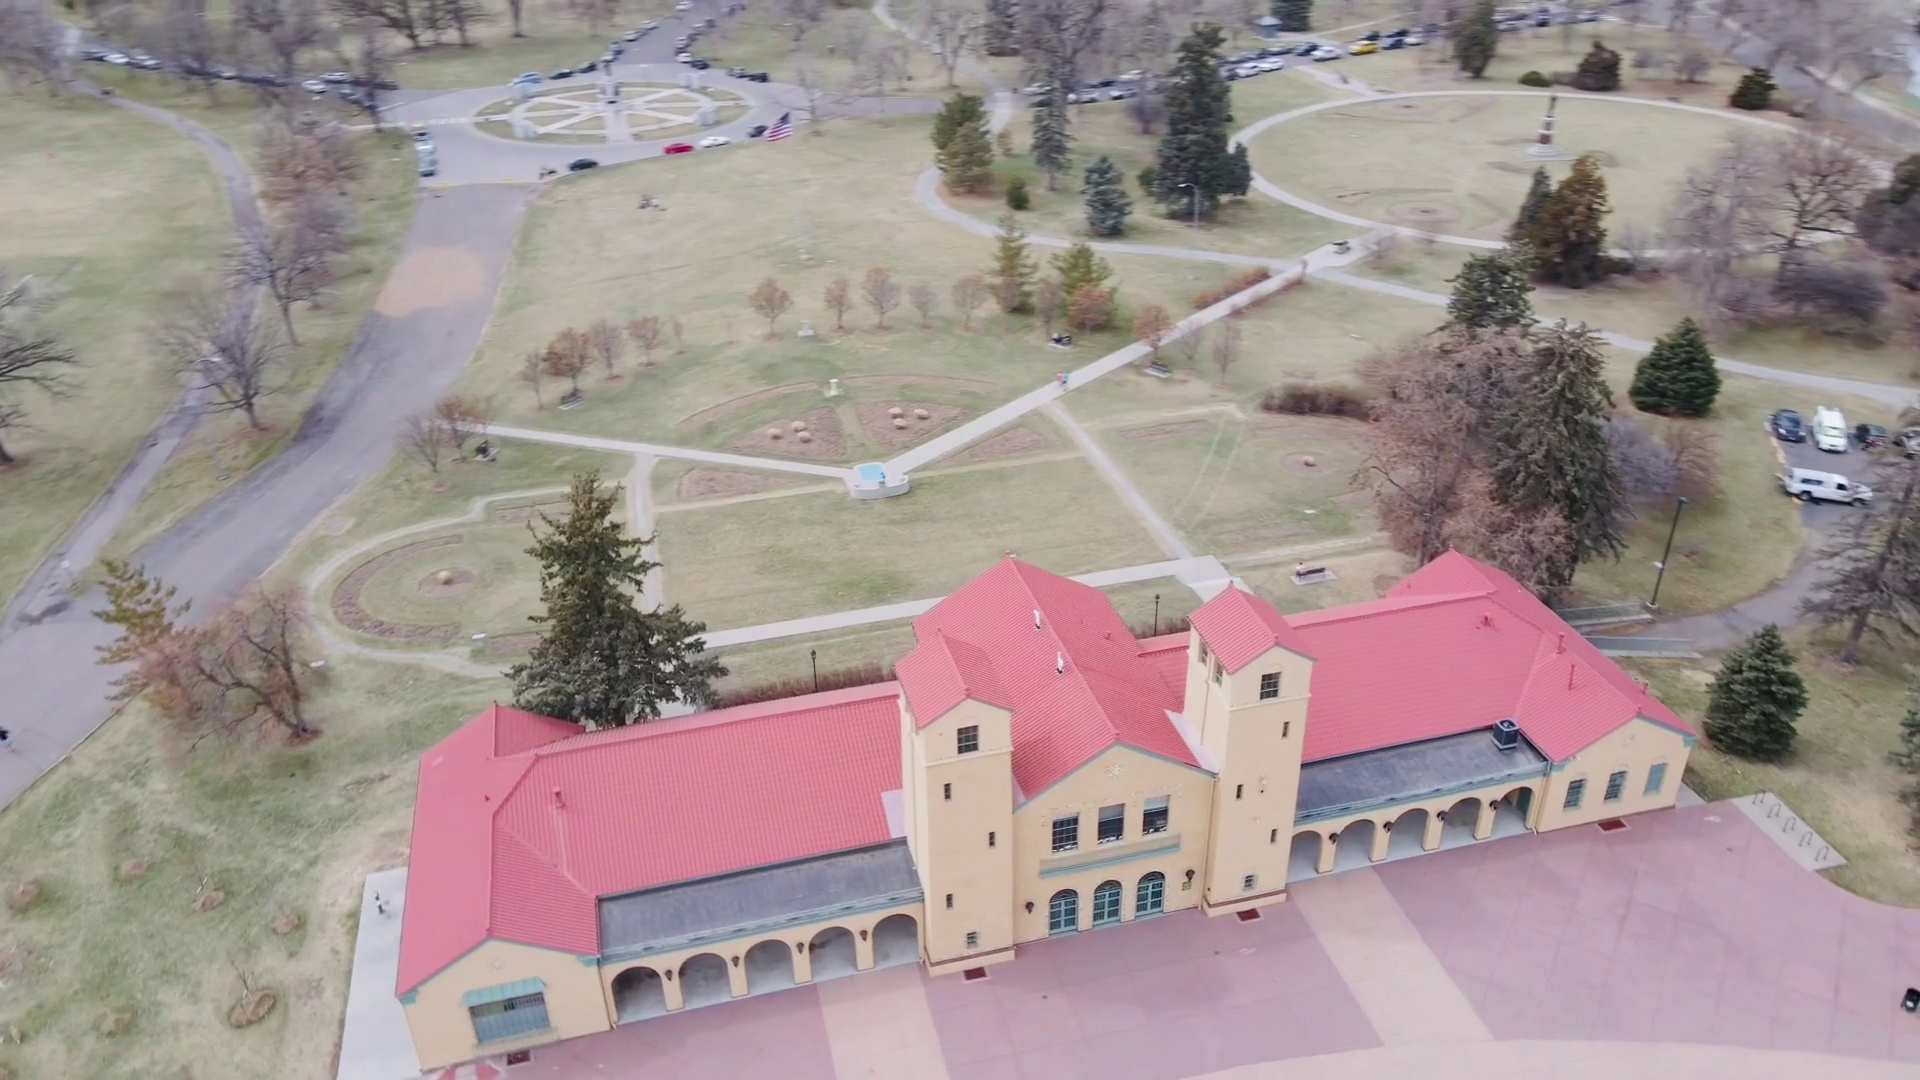

In [ ]:
from IPython.display import Image, display
cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
for pct in [0.6, 0.75, 0.9]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(total * pct))
    ret, frame = cap.read()
    if ret:
        cv2.imwrite(f"/content/check_{int(pct*100)}.jpg", frame)
        display(Image(filename=f"/content/check_{int(pct*100)}.jpg"))
cap.release()

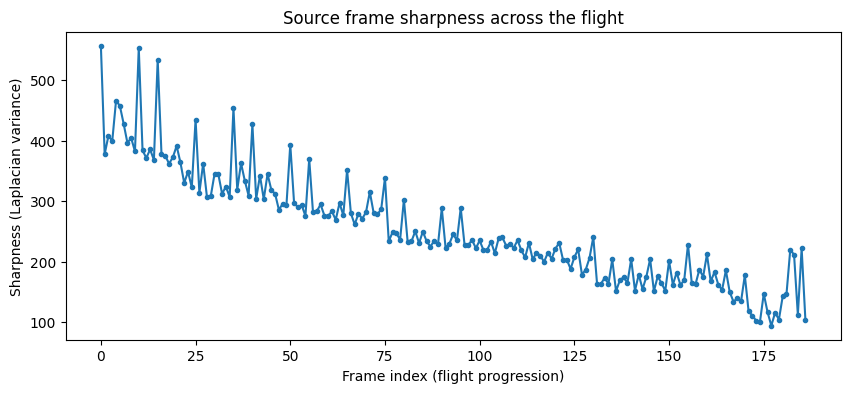

In [ ]:
import cv2, matplotlib.pyplot as plt

frame_files = sorted(OUTPUT_DIR.glob("*.jpg"))
sharpness = [cv2.Laplacian(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var() for f in frame_files]

plt.figure(figsize=(10,4))
plt.plot(sharpness, marker='o', markersize=3)
plt.xlabel("Frame index (flight progression)"); plt.ylabel("Sharpness (Laplacian variance)")
plt.title("Source frame sharpness across the flight")
plt.show()

In [ ]:
try:
    print("DATA_DIR still defined:", DATA_DIR)
    print("Files still present:", os.listdir("/content/outputs/export"))
except NameError:
    print("Kernel restarted — variables are gone, /content is likely wiped")

DATA_DIR still defined: /content/nerfstudio_data
Files still present: ['splat.ply']
